In [1]:
import cfgrib
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import cartopy.crs as ccrs

## Prepare a datafile for Anemoi

In [26]:
datasets = cfgrib.open_datasets(
    "CERRA5.grib",
    backend_kwargs={"indexpath": "", "decode_timedelta": True},
)

/mnt/data/weatherloss/WindPower/WindPower/lib/python3.12/site-packages/cfgrib/xarray_store.py:51: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  o = xr.merge([o, ds], **kwargs)
/mnt/data/weatherloss/WindPower/WindPower/lib/python3.12/site-packages/cfgrib/xarray_store.py:51: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  o = xr.merge([o,

In [107]:
datasets[0]

<xarray.Dataset> Size: 25GB
Dimensions:           (time: 5360, y: 1069, x: 1069)
Coordinates:
  * time              (time) datetime64[ns] 43kB 2023-01-01 ... 2024-10-31T21...
    step              timedelta64[ns] 8B 00:00:00
    entireAtmosphere  float64 8B 0.0
    latitude          (y, x) float64 9MB 20.29 20.31 20.32 ... 63.84 63.81 63.77
    longitude         (y, x) float64 9MB 342.5 342.6 342.6 ... 73.97 74.04 74.11
    valid_time        (time) datetime64[ns] 43kB ...
Dimensions without coordinates: y, x
Data variables:
    mcc               (time, y, x) float32 25GB 14.51 13.72 13.33 ... 0.0 0.0
Attributes:
    GRIB_edition:            2
    GRIB_centre:             eswi
    GRIB_centreDescription:  Norrkoping
    GRIB_subCentre:          255
    Conventions:             CF-1.7
    institution:             Norrkoping

In [73]:
def index_box(ds, lat_min=49.3, lat_max=51.9, lon_min=2.0, lon_max=6.6):
    lat = ds["latitude"].values   # 2-D (y, x)
    lon = ds["longitude"].values  # 2-D (y, x)

    m = (lat >= lat_min) & (lat <= lat_max) & (lon >= lon_min) & (lon <= lon_max)
    yy, xx = np.where(m)
    y0, y1 = int(yy.min()), int(yy.max())
    x0, x1 = int(xx.min()), int(xx.max())
    return slice(y0, y1 + 1), slice(x0, x1 + 1)

cropped = []
for ds in datasets:
    ys, xs = index_box(ds, 49.3, 51.9, 2.0, 6.6)
    dsc = ds.isel(y=ys, x=xs)  # hard crop, no masking → no NaNs

    if "heightAboveGround" in dsc.coords and dsc.coords["heightAboveGround"].size == 1:
        dsc = dsc.reset_coords("heightAboveGround", drop=True)
        dsc=dsc.squeeze()

    cropped.append(dsc)

In [94]:
aligned = xr.align(*cropped, join="inner")  # keep only common coords (e.g., time)
ds = xr.merge(aligned, compat="override", combine_attrs="drop")

Add wind speed at 100m by extrapolating 
(Olaofe, Z. O. (2016). A surface-layer wind speed correction: A case-study of Darling station. Renewable Energy, 93, 228-244.)

In [78]:
#Compute 100 m wind speed (Olaofe 2016), keep dtype like the others, no attrs
w10=ds['si10']
alpha = 0.143
ws100 = (w10 * (100.0 / 10.0) ** alpha).astype(w10.dtype)
ws100 = ws100.rename("ws100")
ws100.attrs = {}  # ensure no fancy metadata
ds = ds.assign(ws100=ws100)

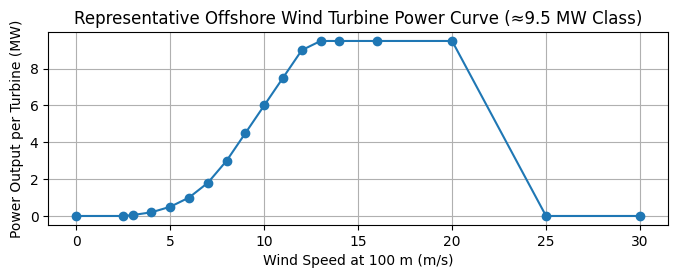

In [79]:
#add synthetic wind power with a power curve 
ws_pts = np.array([0.0, 2.5, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0,
                   11.0, 12.0, 13.0, 14.0, 16.0, 20.0, 25.0, 30.0], dtype="float32")
p_pts  = np.array([0.0, 0.0, 0.05, 0.20, 0.50, 1.00, 1.80, 3.00, 4.50, 6.00,
                   7.50, 9.00, 9.50, 9.50, 9.50, 9.50, 0.00, 0.00], dtype="float32")
plt.figure(figsize=(8, 2.5))
plt.plot(ws_pts, p_pts, marker='o', linestyle='-')
plt.xlabel("Wind Speed at 100 m (m/s)")
plt.ylabel("Power Output per Turbine (MW)")
plt.title("Representative Offshore Wind Turbine Power Curve (≈9.5 MW Class)")
plt.grid(True)
plt.show()

In [80]:
def interp_power(ws):
    return np.interp(ws, ws_pts, p_pts)

In [81]:
wind_power = xr.apply_ufunc(
    np.interp,                          # call NumPy directly
    ds["ws100"],
    kwargs={"xp": ws_pts, "fp": p_pts, "left": 0.0, "right": 0.0},
    input_core_dims=[[]],
    output_core_dims=[[]],
    vectorize=True,                     
    dask="parallelized",               
    output_dtypes=[ds["ws100"].dtype],  
).rename("wind_power")
wind_power.attrs = {}

ds = ds.assign(wind_power=wind_power)

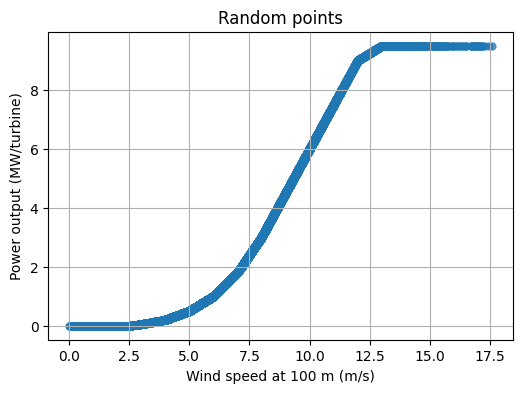

In [82]:
#SANITY CHECK
x=ds["ws100"].isel(time=slice(0,500)).isel(y=slice(0,10)).isel(x=slice(0,10))
y=ds["wind_power"].isel(time=slice(0,500)).isel(y=slice(0,10)).isel(x=slice(0,10))
ws_flat = x.values.ravel()
wp_flat = y.values.ravel()
mask = np.isfinite(ws_flat) & np.isfinite(wp_flat)
ws_flat = ws_flat[mask]; wp_flat = wp_flat[mask]

rng = np.random.default_rng(42)
n = min(100, ws_flat.size)
idx = rng.choice(ws_flat.size, size=n, replace=False)

# ---- plot ----
plt.figure(figsize=(6,4))
plt.scatter(ws_flat, wp_flat, s=25, alpha=0.7)
plt.xlabel("Wind speed at 100 m (m/s)")
plt.ylabel("Power output (MW/turbine)")
plt.title(f"Random points")
plt.grid(True)
plt.show()

In [89]:
nan_counts = {var: ds[var].isnull().sum().item() for var in ds.data_vars}
print(nan_counts)

{'mcc': 0, 't2m': 0, 'si10': 0, 'wdir10': 0, 'msl': 0, 'sr': 0, 'orog': 0, 'ws100': 0, 'wind_power': 0}


In [90]:
ds.to_netcdf(
    "CERRA5_Belgium.nc",
    engine="netcdf4"
)

In [2]:
ds=xr.open_dataset("CERRA5_Belgium.nc")

In [101]:
def plot_cerra_domain_with_belgium_box(
    ds, lat_min=49.3, lat_max=51.9, lon_min=2.0, lon_max=6.6,
    extent=(-20, 20, 30, 60)  # (lon_w, lon_e, lat_s, lat_n)
):
    lat = ds["latitude"].values
    lon = ds["longitude"].values

    # Wrap longitudes to [-180, 180] *for plotting only*
    lon_plot = ((lon + 180) % 360) - 180

    fig = plt.figure(figsize=(8, 8))
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.coastlines(resolution="10m")
    ax.gridlines(draw_labels=True, linestyle=":", linewidth=0.5)

    # CERRA grid outline
    ax.plot(lon_plot[0, :],  lat[0, :],  transform=ccrs.PlateCarree())
    ax.plot(lon_plot[-1, :], lat[-1, :], transform=ccrs.PlateCarree())
    ax.plot(lon_plot[:, 0],  lat[:, 0],  transform=ccrs.PlateCarree())
    ax.plot(lon_plot[:, -1], lat[:, -1], transform=ccrs.PlateCarree())

    # Zoom to requested area
    ax.set_extent(extent, crs=ccrs.PlateCarree())  # (-20, 20, 30, 60)

    # Belgium box
    rect = mpatches.Rectangle(
        (lon_min, lat_min),
        lon_max - lon_min,
        lat_max - lat_min,
        fill=False, linewidth=2, edgecolor="red",
        transform=ccrs.PlateCarree()
    )
    ax.add_patch(rect)

    ax.set_title("CERRA Grid Outline with Belgium Box (20°W–20°E, 30–60°N)")
    plt.show()

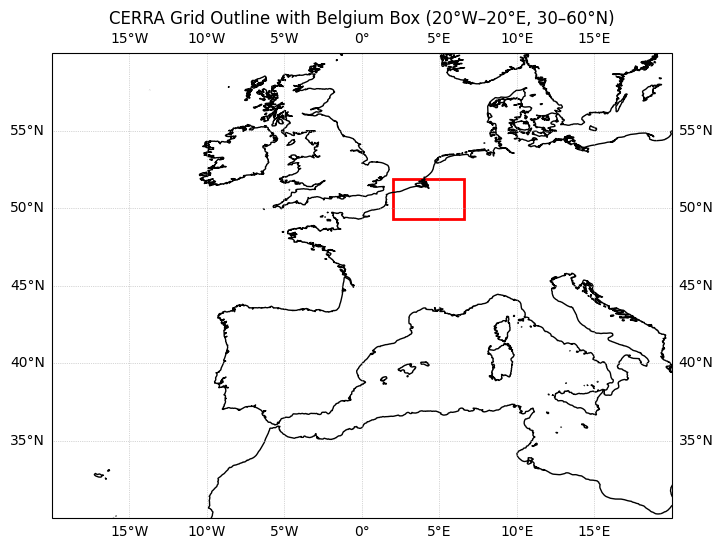

In [102]:
plot_cerra_domain_with_belgium_box(datasets[0], 49.3, 51.9, 2.0, 6.6)

In [20]:
ds

<xarray.Dataset> Size: 648MB
Dimensions:           (time: 5360, y: 55, x: 61)
Coordinates:
  * time              (time) datetime64[ns] 43kB 2023-01-01 ... 2024-10-31T21...
    step              timedelta64[ns] 8B ...
    entireAtmosphere  float64 8B ...
    latitude          (y, x) float64 27kB 49.2 49.21 49.21 ... 52.02 52.02 52.02
    longitude         (y, x) float64 27kB 2.09 2.165 2.241 ... 6.394 6.474 6.554
    valid_time        (time) datetime64[ns] 43kB ...
    meanSea           float64 8B ...
    surface           float64 8B ...
Dimensions without coordinates: y, x
Data variables:
    mcc               (time, y, x) float32 72MB ...
    t2m               (time, y, x) float32 72MB ...
    si10              (time, y, x) float32 72MB ...
    wdir10            (time, y, x) float32 72MB ...
    msl               (time, y, x) float32 72MB ...
    sr                (time, y, x) float32 72MB ...
    orog              (time, y, x) float32 72MB ...
    ws100             (time, y, x) float32 72MB ...
    wind_power        (time, y, x) float32 72MB ...